<a href="https://colab.research.google.com/github/Ansarss/Ai_learning_experiments/blob/main/Las_Vegas_Hotel_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os

print("Files uploaded to Colab:")
for file in os.listdir("/content"):
    print(file)

Files uploaded to Colab:
.config
Electrifind
yelp_cosmopolitan_results.json
yelp_bellagio_results.json
yelp_mgm_results.json
yelp_south_point_results.json
yelp_m_resort_results.json
yelp_venetian_results.json
sample_data


In [10]:
from pathlib import Path

for file in Path("/content").rglob("*"):
    if file.is_file() and file.suffix.lower() in [".csv", ".json", ".xlsx"]:
        print(file)

/content/yelp_cosmopolitan_results.json
/content/yelp_bellagio_results.json
/content/yelp_mgm_results.json
/content/yelp_south_point_results.json
/content/yelp_m_resort_results.json
/content/yelp_venetian_results.json
/content/.config/.last_update_check.json
/content/sample_data/anscombe.json
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_test.csv
/content/Electrifind/notebook/results.csv
/content/Electrifind/notebook/gpt_results.csv
/content/Electrifind/archive/Aspect.csv
/content/Electrifind/data/merged_reviews_and _predicted_dataset.csv
/content/Electrifind/data/relevance.train.csv
/content/Electrifind/data/station_personalized_features.csv
/content/Electrifind/data/NREL_numerical.csv
/content/Electrifind/data/Google_Map_review_data.csv
/content/Electrifind/data/GPT_analysis_AA_DTW.csv
/content/Electrifind/data/relevance.test.csv
/content/Electrifind/data/NREL_ra

In [11]:
import json
import os
import pandas as pd

# List of hotel review files
hotel_files = {
    "Cosmopolitan": "yelp_cosmopolitan_results.json",
    "Bellagio": "yelp_bellagio_results.json",
    "MGM": "yelp_mgm_results.json",
    "South Point": "yelp_south_point_results.json",
    "M Resort": "yelp_m_resort_results.json",
    "Venetian": "yelp_venetian_results.json"
}

# Inspect the structure of each file
for hotel, filename in hotel_files.items():
    filepath = os.path.join("/content", filename)

    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)

    print(f"\nHotel: {hotel}")
    print("Data type:", type(data).__name__)

    if isinstance(data, list):
        print("Number of records:", len(data))
        if data:
            print("Sample record:", str(data[0])[:600])

    elif isinstance(data, dict):
        print("Top-level keys:", list(data.keys()))
        print("Sample content:", str(data)[:600])



Hotel: Cosmopolitan
Data type: list
Number of records: 5040
Sample record: {'review_url': 'https://www.yelp.com/biz/the-cosmopolitan-of-las-vegas-las-vegas?hrid=Q_EaHRyBF1zW4ItOVu63hA', 'id': 'Q_EaHRyBF1zW4ItOVu63hA', 'date': '2021-04-21', 'rating': 5, 'review_title': '', 'review_text': 'I went to Vegas last weekend, and my stay at the Cosmopolitan was very nice !! The room was very spacious and very clean . The view was amazing as well as romantic ! The bathroom was nice with a walk-in shower as well as a jacuzzi bathtub. Absolutely loved the atmosphere !! Will definitely stay there on my next stay!', 'lang_code': 'en', 'author_avatar': 'https://s3-media0.fl.yelpcdn

Hotel: Bellagio
Data type: list
Number of records: 3884
Sample record: {'review_url': 'https://www.yelp.com/biz/bellagio-hotel-las-vegas-6?hrid=RhALcGWhtsHkaY5VJkDvWg', 'id': 'RhALcGWhtsHkaY5VJkDvWg', 'date': '2021-04-17', 'rating': 4, 'review_title': '', 'review_text': 'Beautiful grounds.  Great service. The cleaning in

In [12]:

import pandas as pd
import json
import os

hotel_files = {
    "Cosmopolitan": "yelp_cosmopolitan_results.json",
    "Bellagio": "yelp_bellagio_results.json",
    "MGM Grand": "yelp_mgm_results.json",
    "South Point": "yelp_south_point_results.json",
    "M Resort": "yelp_m_resort_results.json",
    "Venetian": "yelp_venetian_results.json"
}

all_reviews = []

for hotel, filename in hotel_files.items():
    filepath = os.path.join("/content", filename)

    with open(filepath, "r", encoding="utf-8") as f:
        reviews = json.load(f)

    hotel_df = pd.DataFrame(reviews)
    hotel_df["hotel"] = hotel

    all_reviews.append(hotel_df)

# Combine reviews into one dataset
df = pd.concat(all_reviews, ignore_index=True)

# Keep essential research columns
df = df[
    ["hotel", "review_text", "rating", "date", "id"]
].copy()

# Create sentiment categories
def classify_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["sentiment"] = df["rating"].apply(
    lambda x: classify_sentiment(x) if pd.notna(x) else None
)

print("Total reviews:", len(df))
print("\nSentiment distribution:")
print(df["sentiment"].value_counts(dropna=False))

print("\nReviews per hotel:")
print(df["hotel"].value_counts())

print("\nSample records:")
display(df.head())


Total reviews: 21019

Sentiment distribution:
sentiment
Positive    12785
Negative     5685
Neutral      2549
Name: count, dtype: int64

Reviews per hotel:
hotel
Cosmopolitan    5040
MGM Grand       4684
Venetian        4148
Bellagio        3884
South Point     1920
M Resort        1343
Name: count, dtype: int64

Sample records:


,hotel,review_text,rating,date,id,sentiment
0,Cosmopolitan,"I went to Vegas last weekend, and my stay at t...",5,2021-04-21,Q_EaHRyBF1zW4ItOVu63hA,Positive
1,Cosmopolitan,Upon creating the reservation through a third ...,1,2021-04-21,aVGfGoPSL9Po2UCGQPTWXg,Negative
2,Cosmopolitan,I am beyond excited to share my experience at ...,5,2021-04-20,50dGi5BIhqbU_PCioOnqYA,Positive
3,Cosmopolitan,I booked my wedding party here for a destinati...,1,2021-04-19,J-S28RNPkaXpGnmiumazww,Negative
4,Cosmopolitan,Our second stay at Cosmo for Easter vacation a...,5,2021-04-19,N-EhmAXqTxTE1kJoz5PXSQ,Positive


Hotel Customer Satisfaction Comparison:


,total_reviews,average_rating,positive_reviews,negative_reviews,neutral_reviews,positive_percentage
hotel,,,,,,
Venetian,4148,3.85,3002,768,378,72.37
M Resort,1343,3.82,965,266,112,71.85
Cosmopolitan,5040,3.83,3566,1045,429,70.75
Bellagio,3884,3.56,2390,1010,484,61.53
South Point,1920,3.40,1110,514,296,57.81
MGM Grand,4684,2.78,1752,2082,850,37.40


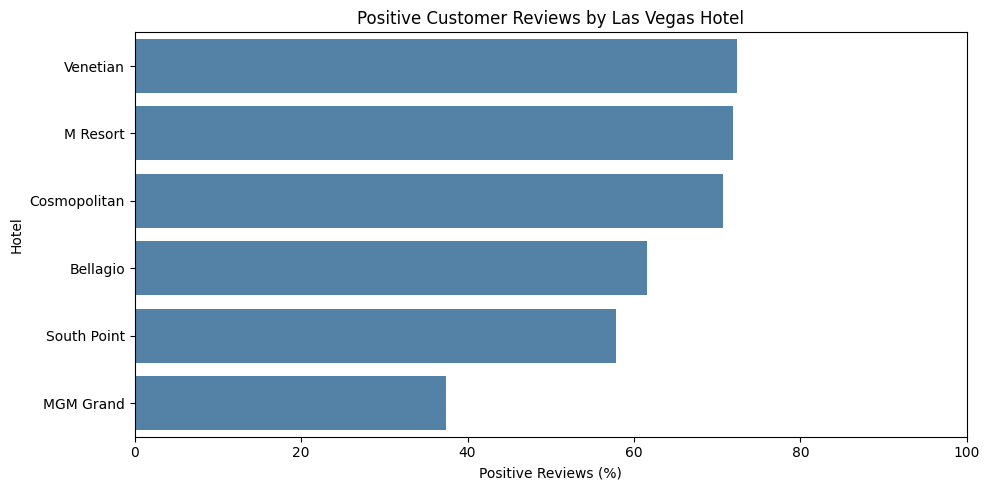

In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate hotel-level statistics
hotel_summary = (
    df.groupby("hotel")
    .agg(
        total_reviews=("rating", "count"),
        average_rating=("rating", "mean"),
        positive_reviews=(
            "sentiment",
            lambda x: (x == "Positive").sum()
        ),
        negative_reviews=(
            "sentiment",
            lambda x: (x == "Negative").sum()
        ),
        neutral_reviews=(
            "sentiment",
            lambda x: (x == "Neutral").sum()
        )
    )
)

hotel_summary["positive_percentage"] = (
    hotel_summary["positive_reviews"] /
    hotel_summary["total_reviews"] * 100
)

hotel_summary = hotel_summary.sort_values(
    "positive_percentage",
    ascending=False
)

print("Hotel Customer Satisfaction Comparison:")
display(hotel_summary.round(2))

# Visualize percentage of positive reviews
plt.figure(figsize=(10, 5))

sns.barplot(
    data=hotel_summary.reset_index(),
    x="positive_percentage",
    y="hotel",
    color="steelblue"
)

plt.title("Positive Customer Reviews by Las Vegas Hotel")
plt.xlabel("Positive Reviews (%)")
plt.ylabel("Hotel")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


In [14]:

import re
import nltk
import pandas as pd

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import wordpunct_tokenize

# Download required NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")

# Remove missing or empty reviews
df = df.dropna(subset=["review_text", "sentiment"]).copy()
df = df[df["review_text"].str.strip() != ""].copy()

# Initialize NLP tools
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

# Preserve words important for sentiment
negations = {"no", "not", "nor", "never"}
stop_words = stop_words - negations

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs and HTML
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)

    # Expand common negations
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"\bcan't\b", "can not", text)
    text = re.sub(r"\bwon't\b", "will not", text)

    # Tokenize and remove punctuation
    tokens = wordpunct_tokenize(text)
    tokens = [word for word in tokens if word.isalpha()]

    # Remove stop words and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

# Apply preprocessing
df["cleaned_text"] = df["review_text"].apply(preprocess_text)

# Remove reviews with no remaining words
df = df[df["cleaned_text"].str.strip() != ""].copy()

print("Reviews after preprocessing:", len(df))

# Compare original and cleaned review
print("\nORIGINAL REVIEW:")
print(df.iloc[0]["review_text"])

print("\nCLEANED REVIEW:")
print(df.iloc[0]["cleaned_text"])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Reviews after preprocessing: 21019

ORIGINAL REVIEW:
I went to Vegas last weekend, and my stay at the Cosmopolitan was very nice !! The room was very spacious and very clean . The view was amazing as well as romantic ! The bathroom was nice with a walk-in shower as well as a jacuzzi bathtub. Absolutely loved the atmosphere !! Will definitely stay there on my next stay!

CLEANED REVIEW:
went vega last weekend stay cosmopolitan nice room spacious clean view amazing well romantic bathroom nice walk shower well jacuzzi bathtub absolutely loved atmosphere definitely stay next stay


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Input features and target labels
X = df["cleaned_text"]
y = df["sentiment"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# Fit TF-IDF only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform testing data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

print("\nTF-IDF training matrix:", X_train_tfidf.shape)
print("TF-IDF testing matrix:", X_test_tfidf.shape)

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())


Training reviews: 16815
Testing reviews: 4204

TF-IDF training matrix: (16815, 10000)
TF-IDF testing matrix: (4204, 10000)

Training sentiment distribution:
sentiment
Positive    10228
Negative     4548
Neutral      2039
Name: count, dtype: int64

Testing sentiment distribution:
sentiment
Positive    2557
Negative    1137
Neutral      510
Name: count, dtype: int64


Naive Bayes Accuracy: 0.8166

Classification Report:
              precision    recall  f1-score   support

    Negative     0.7959    0.8470    0.8206      1137
     Neutral     0.4545    0.0098    0.0192       510
    Positive     0.8263    0.9640    0.8899      2557

    accuracy                         0.8166      4204
   macro avg     0.6923    0.6069    0.5766      4204
weighted avg     0.7730    0.8166    0.7655      4204



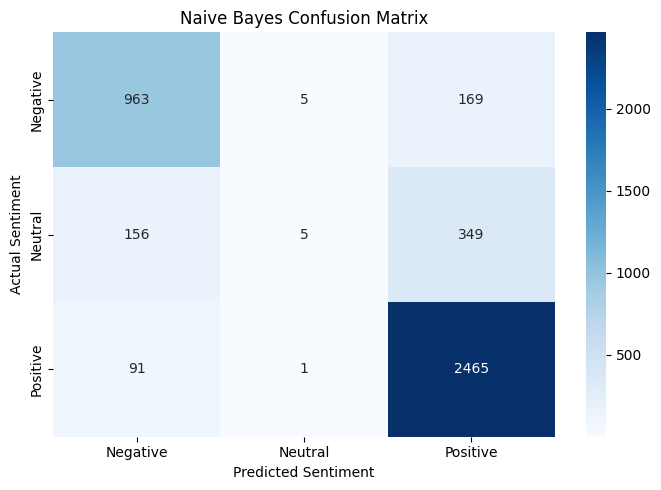

In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train Naive Bayes
nb_model = MultinomialNB(alpha=1.0)

nb_model.fit(X_train_tfidf, y_train)

# Predict sentiment on test data
nb_predictions = nb_model.predict(X_test_tfidf)

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", round(nb_accuracy, 4))

# Detailed performance evaluation
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        nb_predictions,
        digits=4,
        zero_division=0
    )
)

# Create confusion matrix
labels = ["Negative", "Neutral", "Positive"]

cm = confusion_matrix(
    y_test,
    nb_predictions,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()


In [17]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score
)

# Initialize Logistic Regression
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

# Predict test sentiment
lr_predictions = lr_model.predict(X_test_tfidf)

# Evaluate performance
lr_accuracy = accuracy_score(y_test, lr_predictions)

lr_macro_f1 = f1_score(
    y_test,
    lr_predictions,
    average="macro"
)

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
print("Logistic Regression Macro F1:", round(lr_macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lr_predictions,
        digits=4,
        zero_division=0
    )
)


Logistic Regression Accuracy: 0.803
Logistic Regression Macro F1: 0.7101

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8099    0.8320    0.8208      1137
     Neutral     0.3656    0.4961    0.4210       510
    Positive     0.9288    0.8514    0.8884      2557

    accuracy                         0.8030      4204
   macro avg     0.7014    0.7265    0.7101      4204
weighted avg     0.8283    0.8030    0.8134      4204



In [19]:

from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# Initialize Linear SVM
svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# Predict sentiment on the test set
svm_predictions = svm_model.predict(X_test_tfidf)

# Evaluate performance
svm_accuracy = accuracy_score(y_test, svm_predictions)

svm_macro_f1 = f1_score(
    y_test,
    svm_predictions,
    average="macro"
)

print("SVM Accuracy:", round(svm_accuracy, 4))
print("SVM Macro F1:", round(svm_macro_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_predictions,
        digits=4,
        zero_division=0
    )
)


SVM Accuracy: 0.8187
SVM Macro F1: 0.6915

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8020    0.8408    0.8210      1137
     Neutral     0.3918    0.3196    0.3521       510
    Positive     0.8948    0.9085    0.9016      2557

    accuracy                         0.8187      4204
   macro avg     0.6962    0.6896    0.6915      4204
weighted avg     0.8087    0.8187    0.8131      4204



Model Performance Comparison:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Naive Bayes,0.8166,0.6923,0.6069,0.5766
1,Logistic Regression,0.8030,0.7014,0.7265,0.7101
2,SVM,0.8187,0.6962,0.6896,0.6915


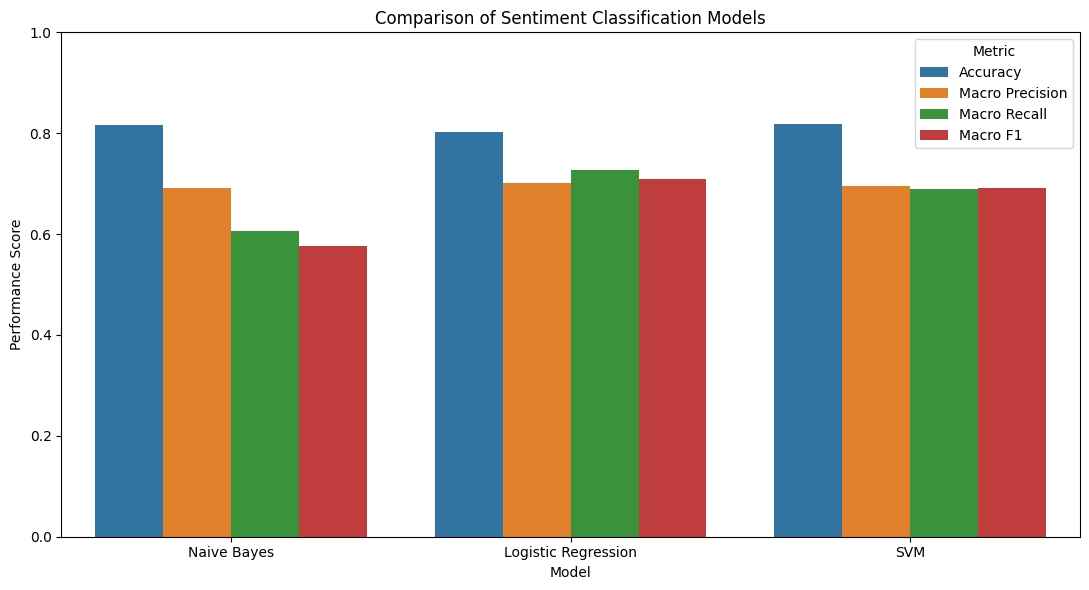

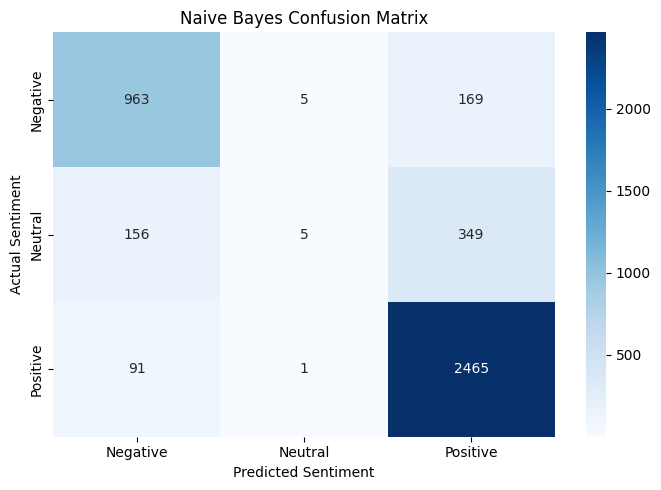

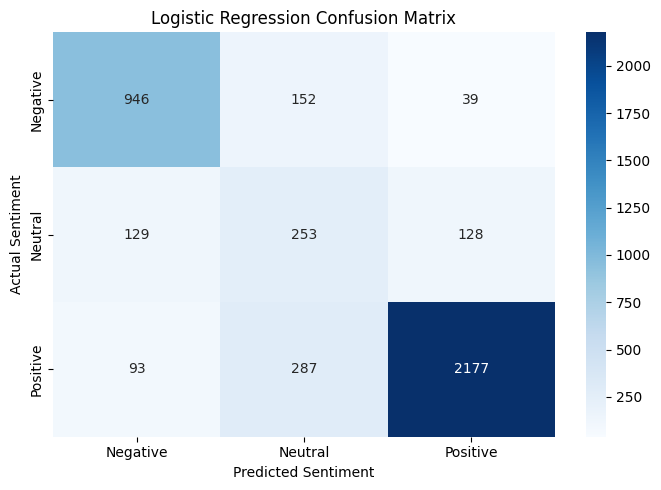

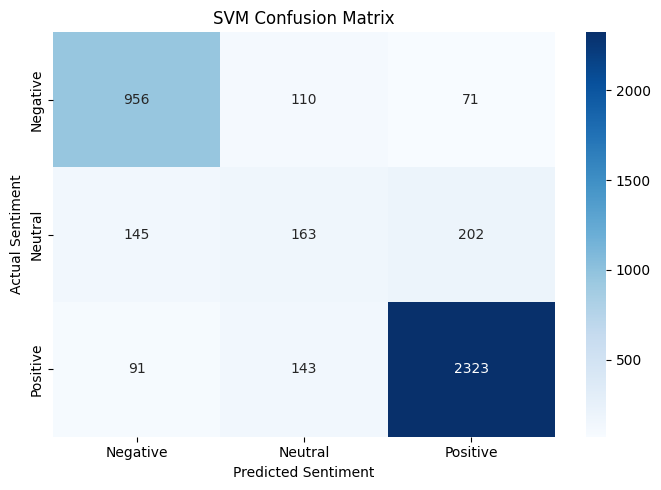

In [20]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Collect predictions from all three models
predictions = {
    "Naive Bayes": nb_predictions,
    "Logistic Regression": lr_predictions,
    "SVM": svm_predictions
}

# Calculate consistent performance metrics
results = []

for model_name, y_pred in predictions.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(
            y_test, y_pred, average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_test, y_pred, average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_test, y_pred, average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

print("Model Performance Comparison:")
display(results_df.round(4))

# Save comparison table
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

# Plot performance comparison
plot_df = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Comparison of Sentiment Classification Models")
plt.ylabel("Performance Score")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    "model_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Generate a separate confusion matrix for each model
labels = ["Negative", "Neutral", "Positive"]

for model_name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Sentiment")
    plt.ylabel("Actual Sentiment")
    plt.tight_layout()

    filename = (
        model_name.lower().replace(" ", "_")
        + "_confusion_matrix.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()



Top 15 features associated with Negative:


,Feature,Coefficient
0,worst,4.124690
1,never,3.159736
2,not,3.080740
3,told,3.057135
4,disappointed,2.905416
5,rude,2.529740
6,dirty,2.477991
7,no,2.316081
8,never stay,2.308436
9,terrible,2.293571


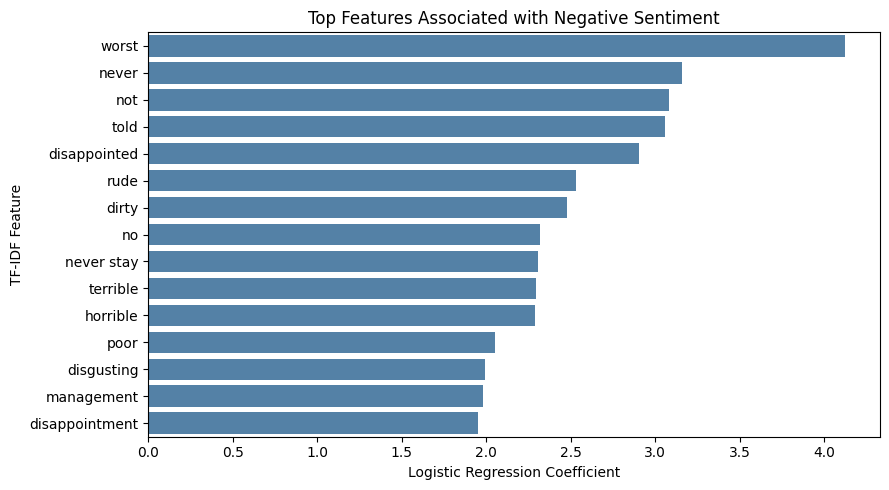


Top 15 features associated with Neutral:


,Feature,Coefficient
0,ok,2.581553
1,three star,2.490981
2,however,2.338385
3,prefer,2.315137
4,not,2.296096
5,decent,2.024715
6,hotel nice,1.917378
7,nice,1.900824
8,okay,1.891823
9,not great,1.862935


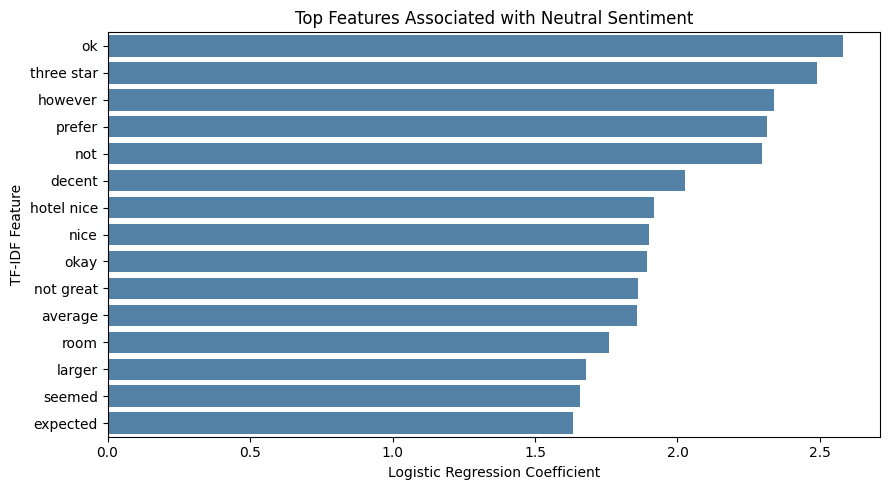


Top 15 features associated with Positive:


,Feature,Coefficient
0,great,4.721578
1,love,4.176172
2,amazing,3.936221
3,best,3.468116
4,beautiful,3.292082
5,awesome,3.226254
6,perfect,2.846029
7,favorite,2.820942
8,gorgeous,2.607177
9,definitely,2.575535


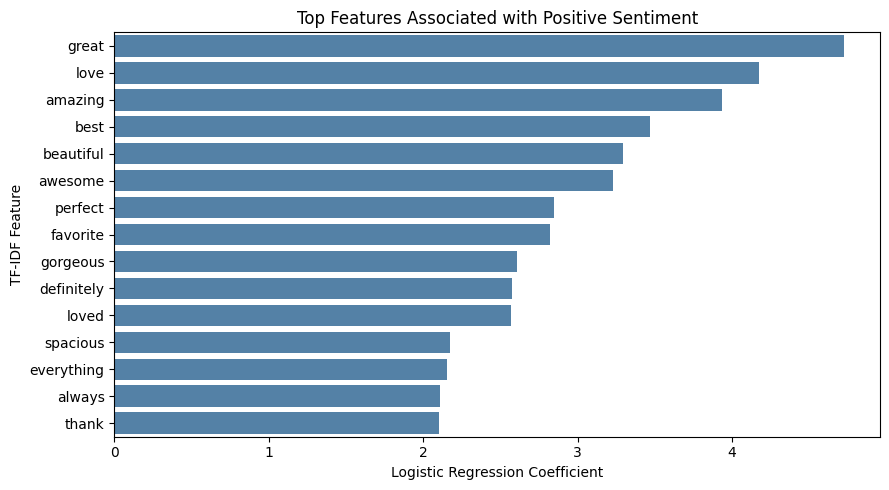

In [21]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve TF-IDF feature names
feature_names = np.array(
    tfidf.get_feature_names_out()
)

# Retrieve sentiment classes
classes = lr_model.classes_

# Extract top features for each sentiment
top_n = 15

for i, sentiment in enumerate(classes):

    coefficients = lr_model.coef_[i]

    top_indices = np.argsort(coefficients)[-top_n:][::-1]

    top_features = pd.DataFrame({
        "Feature": feature_names[top_indices],
        "Coefficient": coefficients[top_indices]
    })

    print(f"\nTop {top_n} features associated with {sentiment}:")
    display(top_features)

    plt.figure(figsize=(9, 5))

    sns.barplot(
        data=top_features,
        x="Coefficient",
        y="Feature",
        color="steelblue"
    )

    plt.title(f"Top Features Associated with {sentiment} Sentiment")
    plt.xlabel("Logistic Regression Coefficient")
    plt.ylabel("TF-IDF Feature")
    plt.tight_layout()
    plt.show()
